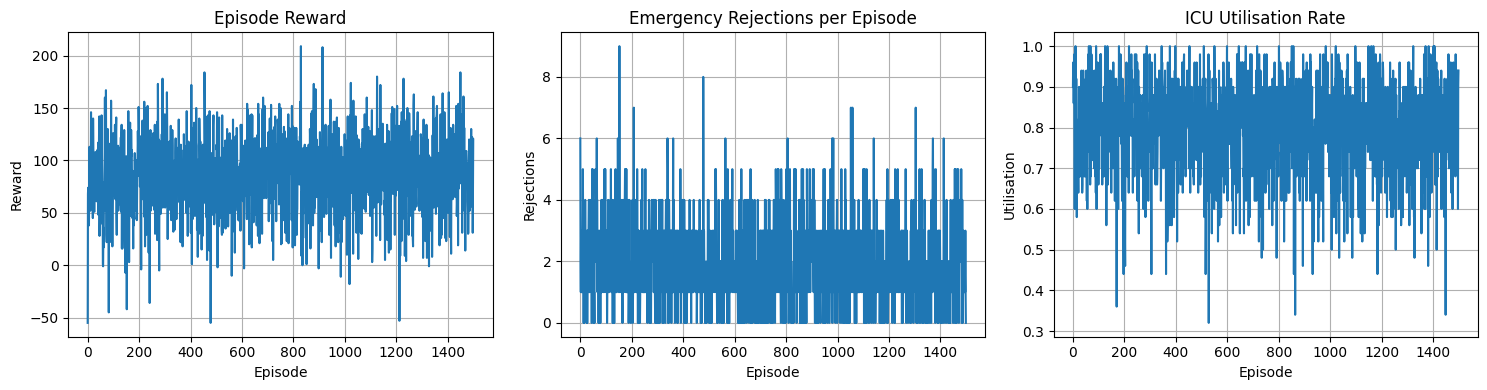

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. ENVIRONMENT
# ---------------------------------------------------------

class HospitalEnv:
    def __init__(self):
        # ICU free: 0,1,2
        # GEN free: 0,1,2,3
        # Patient type: 0=emergency, 1=urgent, 2=elective
        self.reset()

    def reset(self):
        self.icu_free = np.random.randint(0, 3)
        self.gen_free = np.random.randint(0, 4)
        self.ptype = np.random.choice([0,1,2])
        return self._get_state()

    def _get_state(self):
        return (self.icu_free, self.gen_free, self.ptype)

    def step(self, action):
        reward = 0
        icu, gen, p = self.icu_free, self.gen_free, self.ptype

        # -----------------------------
        # APPLY ACTION
        # -----------------------------
        if action == 0:  # allocate ICU
            if icu > 0:
                self.icu_free -= 1
                if p in [0,1]: reward += 5
                else: reward -= 3
            else:
                reward -= 10

        elif action == 1:  # allocate general
            if gen > 0:
                self.gen_free -= 1
                if p == 2: reward += 5
                elif p in [0,1]:
                    if icu > 0: reward -= 3
                    else: reward += 2
            else:
                reward -= 10

        elif action == 2:  # delay
            reward -= 1
            if p == 0:
                reward -= 10

        # -----------------------------
        # DISCHARGES
        # -----------------------------
        if random.random() < 0.3:
            self.icu_free = min(self.icu_free + 1, 2)
        if random.random() < 0.4:
            self.gen_free = min(self.gen_free + 1, 3)

        # -----------------------------
        # EMERGENCY REJECTION LOGIC
        # -----------------------------
        emergency_rejected = 0
        if p == 0:  # emergency patient
            if action == 0 and icu == 0:
                emergency_rejected = 1
            elif action == 1 and gen == 0:
                emergency_rejected = 1
            elif action == 2:
                emergency_rejected = 1

        # ICU utilisation: 1 if at least one ICU bed is occupied
        icu_occupied = 1 if self.icu_free < 2 else 0

        # -----------------------------
        # NEW PATIENT ARRIVAL
        # -----------------------------
        self.ptype = np.random.choice([0,1,2], p=[0.2,0.3,0.5])

        next_state = self._get_state()
        done = False
        return next_state, reward, done, emergency_rejected, icu_occupied


# ---------------------------------------------------------
# 2. Q-LEARNING
# ---------------------------------------------------------

def state_to_index(s):
    icu, gen, p = s
    return icu*12 + gen*3 + p  # 36 states

def run_q_learning(episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.2):
    env = HospitalEnv()
    Q = np.zeros((36, 3))

    rewards_per_episode = []
    emergency_rejections = []
    icu_utilisation = []

    for ep in range(episodes):
        s = env.reset()
        total_reward = 0
        episode_rejections = 0
        episode_icu_occ = 0

        for t in range(50):
            s_idx = state_to_index(s)

            # epsilon-greedy
            if random.random() < epsilon:
                a = np.random.randint(0, 3)
            else:
                a = np.argmax(Q[s_idx])

            s_next, r, done, rej, icu_occ = env.step(a)
            s_next_idx = state_to_index(s_next)

            # Q update
            Q[s_idx, a] += alpha * (r + gamma * np.max(Q[s_next_idx]) - Q[s_idx, a])

            s = s_next
            total_reward += r
            episode_rejections += rej
            episode_icu_occ += icu_occ

        rewards_per_episode.append(total_reward)
        emergency_rejections.append(episode_rejections)
        icu_utilisation.append(episode_icu_occ / 50.0)

    return Q, rewards_per_episode, emergency_rejections, icu_utilisation


# ---------------------------------------------------------
# 3. RUN EXPERIMENT + PLOTS
# ---------------------------------------------------------

Q, rewards, rejections, icu_util = run_q_learning(episodes=1500)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(rewards)
plt.title("Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(rejections)
plt.title("Emergency Rejections per Episode")
plt.xlabel("Episode")
plt.ylabel("Rejections")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(icu_util)
plt.title("ICU Utilisation Rate")
plt.xlabel("Episode")
plt.ylabel("Utilisation")
plt.grid(True)

plt.tight_layout()
plt.show()


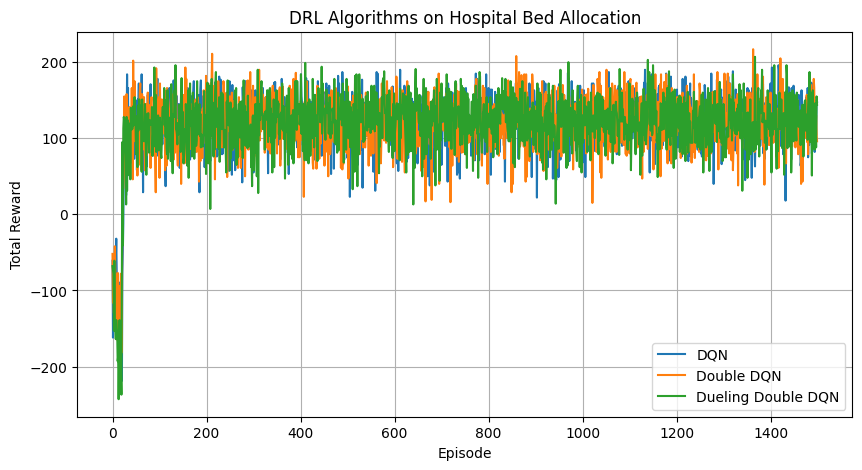

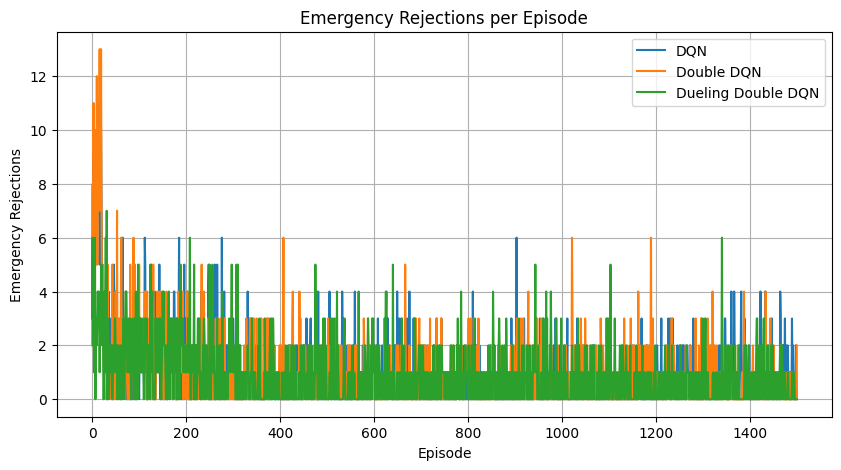

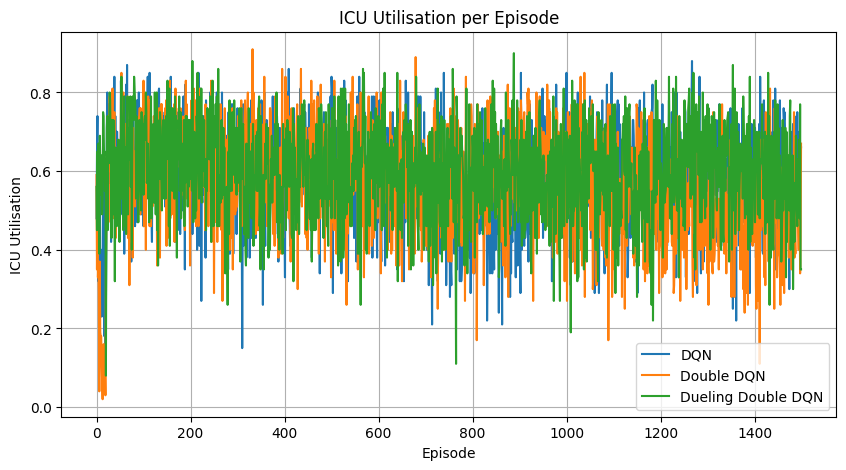

In [4]:
import random
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# State vector conversion
# ---------------------------------------------------------
def state_to_vector(s):
    icu, gen, p = s
    p_onehot = np.zeros(3)
    p_onehot[p] = 1.0
    return np.array([icu, gen] + p_onehot.tolist(), dtype=np.float32)

# ---------------------------------------------------------
# Replay Buffer
# ---------------------------------------------------------
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(states, dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.long, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(next_states, dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)

# ---------------------------------------------------------
# DQN Networks
# ---------------------------------------------------------
class DQN(nn.Module):
    def __init__(self, state_dim=5, action_dim=3, hidden_dim=64):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)

class DuelingDQN(nn.Module):
    def __init__(self, state_dim=5, action_dim=3, hidden_dim=64):
        super(DuelingDQN, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU()
        )
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        self.adv_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        feat = self.feature(x)
        value = self.value_stream(feat)
        adv = self.adv_stream(feat)
        q = value + adv - adv.mean(dim=1, keepdim=True)
        return q

# ---------------------------------------------------------
# TRAINING FUNCTION WITH NEW METRICS
# ---------------------------------------------------------
def train_dqn(
    episodes=1000,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=10000,
    min_buffer_size=1000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=500,
    target_update_freq=50,
    double_dqn=True,
    dueling=False,
    icu_capacity=2
):
    env = HospitalEnv()
    state_dim = 5
    action_dim = 3

    if dueling:
        policy_net = DuelingDQN(state_dim, action_dim).to(device)
        target_net = DuelingDQN(state_dim, action_dim).to(device)
    else:
        policy_net = DQN(state_dim, action_dim).to(device)
        target_net = DQN(state_dim, action_dim).to(device)

    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(capacity=buffer_capacity)

    rewards_per_episode = []
    emergency_rej_per_episode = []
    icu_util_per_episode = []

    steps_done = 0

    for ep in range(episodes):
        s = env.reset()
        s_vec = state_to_vector(s)
        total_reward = 0

        emergency_rej = 0
        icu_util_sum = 0.0
        step_count = 0

        for t in range(50):
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-steps_done / epsilon_decay)
            steps_done += 1

            if random.random() < epsilon:
                a = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    state_t = torch.tensor(np.array([s_vec]), device=device) # Fixed: Convert to numpy array first
                    q_values = policy_net(state_t)
                    a = q_values.argmax(dim=1).item()

            # ICU utilisation: calculated based on the state *before* the action
            icu_free, gen_free, ptype = s
            icu_occupied_beds = icu_capacity - icu_free
            icu_util_sum += icu_occupied_beds / icu_capacity
            step_count += 1

            # Call env.step and unpack all 5 return values
            # The 5 values are: next_state, reward, done, emergency_rejected, icu_occupied_flag
            # We use 'emergency_rejected_from_env' for the metric and discard 'icu_occupied_flag_from_env'
            s_next, r, done, emergency_rejected_from_env, _ = env.step(a)

            # Update emergency rejection metric using the value from env.step
            emergency_rej += emergency_rejected_from_env

            s_next_vec = state_to_vector(s_next)

            replay_buffer.push(s_vec, a, r, s_next_vec, done)

            s_vec = s_next_vec
            s = s_next
            total_reward += r

            if len(replay_buffer) >= min_buffer_size:
                states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    if double_dqn:
                        next_q_policy = policy_net(next_states)
                        next_actions = next_q_policy.argmax(dim=1, keepdim=True)
                        next_q_target = target_net(next_states).gather(1, next_actions).squeeze(1)
                    else:
                        next_q_target = target_net(next_states).max(dim=1)[0]

                    targets = rewards + gamma * (1 - dones) * next_q_target

                loss = nn.MSELoss()(q_values, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            if done:
                break

        rewards_per_episode.append(total_reward)
        emergency_rej_per_episode.append(emergency_rej)
        icu_util_per_episode.append(icu_util_sum / step_count)

        if ep % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

    return rewards_per_episode, emergency_rej_per_episode, icu_util_per_episode

# ---------------------------------------------------------
# RUN EXPERIMENTS
# ---------------------------------------------------------
rewards_dqn, emrej_dqn, icu_dqn = train_dqn(
    episodes=1500,
    double_dqn=False,
    dueling=False
)

rewards_double, emrej_double, icu_double = train_dqn(
    episodes=1500,
    double_dqn=True,
    dueling=False
)

rewards_dueling, emrej_dueling, icu_dueling = train_dqn(
    episodes=1500,
    double_dqn=True,
    dueling=True
)

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------

# Reward plot
plt.figure(figsize=(10,5))
plt.plot(rewards_dqn, label="DQN")
plt.plot(rewards_double, label="Double DQN")
plt.plot(rewards_dueling, label="Dueling Double DQN")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DRL Algorithms on Hospital Bed Allocation")
plt.legend()
plt.grid(True)
plt.show()

# Emergency rejections
plt.figure(figsize=(10,5))
plt.plot(emrej_dqn, label="DQN")
plt.plot(emrej_double, label="Double DQN")
plt.plot(emrej_dueling, label="Dueling Double DQN")
plt.xlabel("Episode")
plt.ylabel("Emergency Rejections")
plt.title("Emergency Rejections per Episode")
plt.legend()
plt.grid(True)
plt.show()

# ICU utilisation
plt.figure(figsize=(10,5))
plt.plot(icu_dqn, label="DQN")
plt.plot(icu_double, label="Double DQN")
plt.plot(icu_dueling, label="Dueling Double DQN")
plt.xlabel("Episode")
plt.ylabel("ICU Utilisation")
plt.title("ICU Utilisation per Episode")
plt.legend()
plt.grid(True)
plt.show()
